# Milestone 1: Video Analytics Pipeline

## Basic Detection and Tracking Pipeline

**Authors:** Bhanu Prakash Vangala, Nolan Rink

---

### Overview

This milestone implements a basic video analytics pipeline with:
1. **Object Detection** using YOLOv8
2. **Object Tracking** using OC-SORT
3. **Performance Metrics** collection

---

In [1]:
# Imports
import torch
import numpy as np
import cv2
import os
import time
import json
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("MILESTONE 1: VIDEO ANALYTICS PIPELINE")
print("="*70)

MILESTONE 1: VIDEO ANALYTICS PIPELINE


---
## Setup and Configuration
---

In [2]:
# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Load YOLOv8 model
model = YOLO('yolov8n.pt')
print("Model loaded: YOLOv8n")

# Dataset path
DATASET_PATH = '../Dataset/MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = '../MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = 'MOT17/train/MOT17-04-DPM/img1'

all_images = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith('.jpg')])
NUM_FRAMES = 100
image_files = [os.path.join(DATASET_PATH, f) for f in all_images[:NUM_FRAMES]]
print(f"Dataset: {len(image_files)} frames from MOT17-04-DPM")

Device: cpu
Model loaded: YOLOv8n
Dataset: 100 frames from MOT17-04-DPM


---
## OC-SORT Tracker Implementation

OC-SORT (Observation-Centric SORT) is a multi-object tracking algorithm that:
- Uses IoU-based association
- Maintains track states across frames
- Handles occlusions and re-identification

---

In [3]:
class OCSort:
    """
    OC-SORT: Observation-Centric SORT Tracker
    
    A simple yet effective multi-object tracker using:
    - IoU-based association
    - Hungarian algorithm for optimal matching
    - Track management (creation, update, deletion)
    """
    
    def __init__(self, det_thresh=0.3, max_age=30, min_hits=3, iou_threshold=0.3):
        self.det_thresh = det_thresh      # Detection confidence threshold
        self.max_age = max_age            # Max frames to keep lost track
        self.min_hits = min_hits          # Min hits before track is confirmed
        self.iou_threshold = iou_threshold # IoU threshold for matching
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1

    def reset(self):
        """Reset tracker state"""
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1

    def update(self, detections):
        """
        Update tracker with new detections.
        
        Args:
            detections: Array of [x1, y1, x2, y2, conf] or torch tensor
            
        Returns:
            List of [x1, y1, x2, y2, track_id, conf]
        """
        self.frame_count += 1
        
        # Convert tensor to numpy
        if torch.is_tensor(detections):
            detections = detections.cpu().numpy()
        
        # Filter by confidence
        if len(detections) > 0:
            detections = detections[detections[:, 4] >= self.det_thresh]

        # Age all trackers
        for tracker in self.trackers:
            tracker['age'] += 1

        # Match detections to existing trackers
        if len(detections) > 0 and len(self.trackers) > 0:
            # Build IoU matrix
            iou_matrix = np.zeros((len(detections), len(self.trackers)))
            for d, det in enumerate(detections):
                for t, tracker in enumerate(self.trackers):
                    iou_matrix[d, t] = self._iou(det[:4], tracker['bbox'])

            # Hungarian algorithm for optimal assignment
            det_indices, track_indices = linear_sum_assignment(-iou_matrix)
            
            # Filter matches by IoU threshold
            matched = []
            for d, t in zip(det_indices, track_indices):
                if iou_matrix[d, t] >= self.iou_threshold:
                    matched.append((d, t))
            matched_dets = set(m[0] for m in matched)

            # Update matched trackers
            for det_idx, track_idx in matched:
                self.trackers[track_idx]['bbox'] = detections[det_idx][:4]
                self.trackers[track_idx]['score'] = detections[det_idx][4]
                self.trackers[track_idx]['age'] = 0
                self.trackers[track_idx]['hits'] += 1

            # Create new trackers for unmatched detections
            for d in range(len(detections)):
                if d not in matched_dets:
                    self.trackers.append({
                        'id': self.track_id_count,
                        'bbox': detections[d][:4],
                        'score': detections[d][4],
                        'age': 0,
                        'hits': 1
                    })
                    self.track_id_count += 1
                    
        elif len(detections) > 0:
            # No existing trackers, create new ones
            for det in detections:
                self.trackers.append({
                    'id': self.track_id_count,
                    'bbox': det[:4],
                    'score': det[4],
                    'age': 0,
                    'hits': 1
                })
                self.track_id_count += 1

        # Remove dead trackers
        self.trackers = [t for t in self.trackers if t['age'] <= self.max_age]

        # Return confirmed tracks
        results = []
        for tracker in self.trackers:
            if tracker['hits'] >= self.min_hits or self.frame_count <= self.min_hits:
                results.append([
                    tracker['bbox'][0], tracker['bbox'][1],
                    tracker['bbox'][2], tracker['bbox'][3],
                    tracker['id'], tracker['score']
                ])
        return results

    def _iou(self, box1, box2):
        """Calculate Intersection over Union"""
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])
        
        if x2 <= x1 or y2 <= y1:
            return 0.0
        
        intersection = (x2 - x1) * (y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union = area1 + area2 - intersection
        
        return intersection / (union + 1e-6)

print("OC-SORT Tracker defined!")

OC-SORT Tracker defined!


---
## Run Video Pipeline
---

In [4]:
print("\n" + "="*70)
print("RUNNING VIDEO PIPELINE")
print("="*70)

# Initialize tracker
tracker = OCSort()

# Metrics collection
metrics = {
    'frame_times': [],
    'detection_times': [],
    'tracking_times': [],
    'detections_per_frame': [],
    'tracks_per_frame': [],
    'confidences': []
}

all_tracks = []

# Process frames
for frame_idx, img_path in enumerate(image_files):
    frame_start = time.time()
    
    # Load image
    image = Image.open(img_path).convert("RGB")
    
    # Detection
    det_start = time.time()
    results = model(image, verbose=False)
    det_time = (time.time() - det_start) * 1000
    
    # Extract person detections (class 0)
    frame_dets = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for i, class_id in enumerate(boxes.cls):
                if int(class_id) == 0:  # Person class
                    box = boxes.xyxy[i].cpu().numpy()
                    conf = float(boxes.conf[i])
                    if conf >= 0.3:
                        frame_dets.append([box[0], box[1], box[2], box[3], conf])
                        metrics['confidences'].append(conf)
    
    metrics['detections_per_frame'].append(len(frame_dets))
    metrics['detection_times'].append(det_time)
    
    # Tracking
    track_start = time.time()
    if frame_dets:
        det_tensor = torch.tensor(np.array(frame_dets))
        tracks = tracker.update(det_tensor)
    else:
        tracks = []
    track_time = (time.time() - track_start) * 1000
    
    metrics['tracks_per_frame'].append(len(tracks))
    metrics['tracking_times'].append(track_time)
    
    # Store tracks
    for track in tracks:
        all_tracks.append({
            'frame': frame_idx,
            'track_id': int(track[4]),
            'bbox': [float(track[0]), float(track[1]), float(track[2]), float(track[3])],
            'confidence': float(track[5])
        })
    
    frame_time = (time.time() - frame_start) * 1000
    metrics['frame_times'].append(frame_time)
    
    if (frame_idx + 1) % 20 == 0:
        print(f"Frame {frame_idx+1}/{len(image_files)} - Det: {len(frame_dets)}, Tracks: {len(tracks)}, Time: {frame_time:.1f}ms")

print("\nPipeline complete!")


RUNNING VIDEO PIPELINE
Frame 20/100 - Det: 21, Tracks: 25, Time: 96.2ms
Frame 40/100 - Det: 17, Tracks: 26, Time: 135.4ms
Frame 60/100 - Det: 20, Tracks: 23, Time: 149.6ms
Frame 80/100 - Det: 19, Tracks: 25, Time: 113.5ms
Frame 100/100 - Det: 20, Tracks: 30, Time: 160.4ms

Pipeline complete!


---
## Performance Metrics
---

In [5]:
print("\n" + "="*70)
print("PERFORMANCE METRICS")
print("="*70)

# Calculate statistics
avg_frame_time = np.mean(metrics['frame_times'])
avg_det_time = np.mean(metrics['detection_times'])
avg_track_time = np.mean(metrics['tracking_times'])
avg_detections = np.mean(metrics['detections_per_frame'])
avg_tracks = np.mean(metrics['tracks_per_frame'])
avg_confidence = np.mean(metrics['confidences']) if metrics['confidences'] else 0

fps = 1000 / avg_frame_time
unique_tracks = len(set(t['track_id'] for t in all_tracks))

print(f"\n{'Metric':<30} {'Value':<20}")
print("-" * 50)
print(f"{'Total Frames':<30} {len(image_files)}")
print(f"{'Avg Frame Time':<30} {avg_frame_time:.2f} ms")
print(f"{'Avg Detection Time':<30} {avg_det_time:.2f} ms")
print(f"{'Avg Tracking Time':<30} {avg_track_time:.2f} ms")
print(f"{'FPS':<30} {fps:.2f}")
print(f"{'Avg Detections/Frame':<30} {avg_detections:.1f}")
print(f"{'Avg Tracks/Frame':<30} {avg_tracks:.1f}")
print(f"{'Unique Track IDs':<30} {unique_tracks}")
print(f"{'Avg Confidence':<30} {avg_confidence:.3f}")


PERFORMANCE METRICS

Metric                         Value               
--------------------------------------------------
Total Frames                   100
Avg Frame Time                 149.07 ms
Avg Detection Time             127.14 ms
Avg Tracking Time              2.05 ms
FPS                            6.71
Avg Detections/Frame           19.8
Avg Tracks/Frame               25.1
Unique Track IDs               38
Avg Confidence                 0.590


---
## Visualizations
---

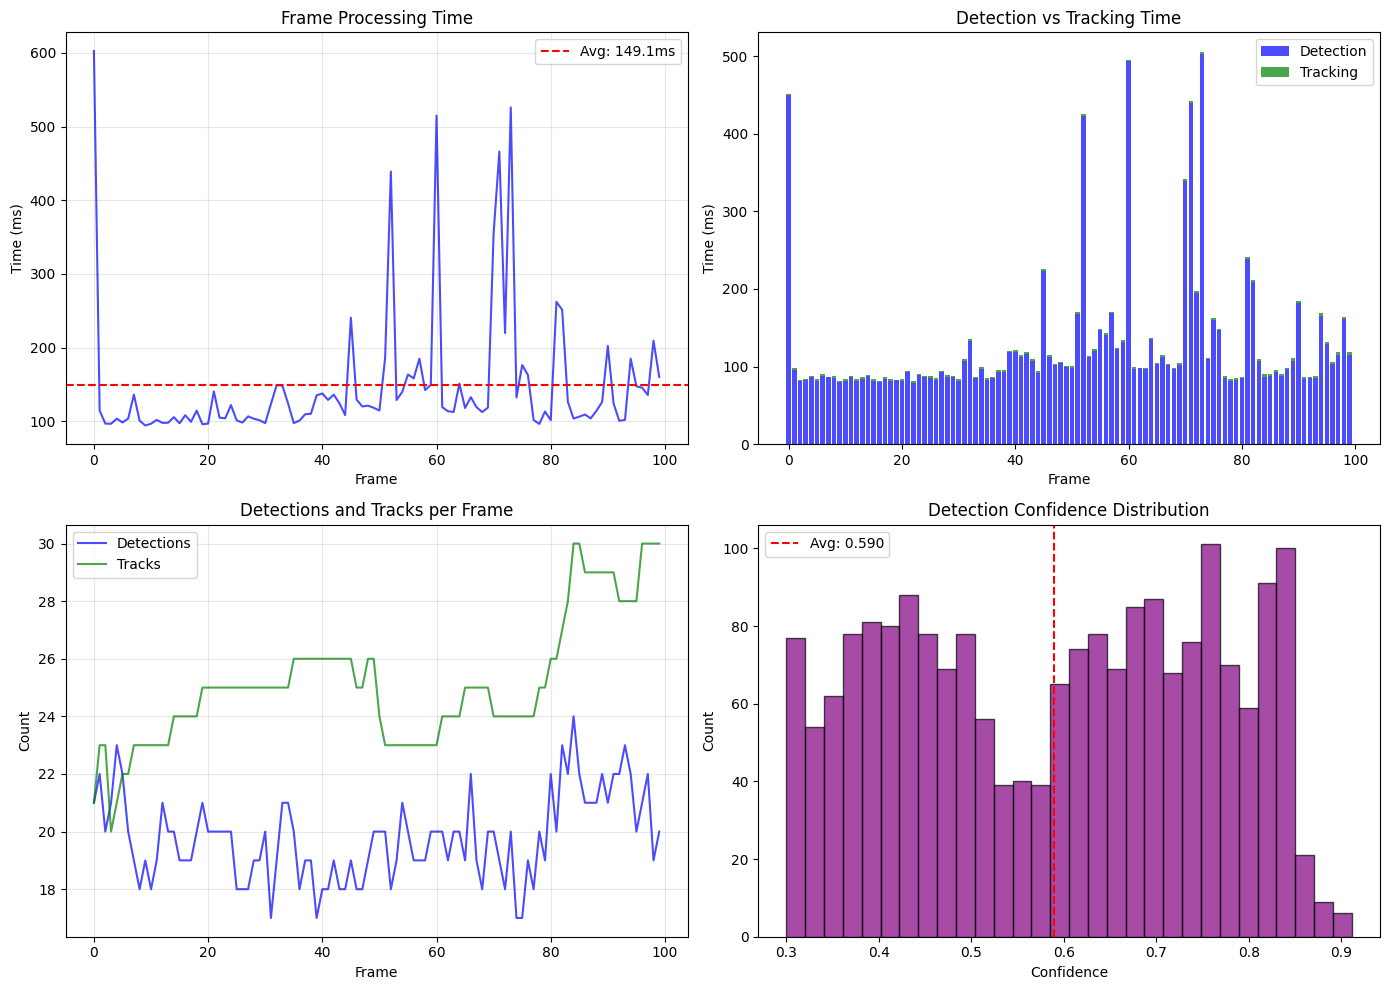

Saved: milestone1_results.png


In [6]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Frame processing time
ax1 = axes[0, 0]
ax1.plot(metrics['frame_times'], 'b-', alpha=0.7)
ax1.axhline(y=avg_frame_time, color='r', linestyle='--', label=f'Avg: {avg_frame_time:.1f}ms')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Time (ms)')
ax1.set_title('Frame Processing Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Detection vs Tracking time
ax2 = axes[0, 1]
x = range(len(metrics['detection_times']))
ax2.bar(x, metrics['detection_times'], alpha=0.7, label='Detection', color='blue')
ax2.bar(x, metrics['tracking_times'], alpha=0.7, bottom=metrics['detection_times'], label='Tracking', color='green')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Detection vs Tracking Time')
ax2.legend()

# 3. Detections and Tracks per frame
ax3 = axes[1, 0]
ax3.plot(metrics['detections_per_frame'], 'b-', label='Detections', alpha=0.7)
ax3.plot(metrics['tracks_per_frame'], 'g-', label='Tracks', alpha=0.7)
ax3.set_xlabel('Frame')
ax3.set_ylabel('Count')
ax3.set_title('Detections and Tracks per Frame')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Confidence distribution
ax4 = axes[1, 1]
ax4.hist(metrics['confidences'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax4.axvline(x=avg_confidence, color='r', linestyle='--', label=f'Avg: {avg_confidence:.3f}')
ax4.set_xlabel('Confidence')
ax4.set_ylabel('Count')
ax4.set_title('Detection Confidence Distribution')
ax4.legend()

plt.tight_layout()
plt.savefig('milestone1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: milestone1_results.png")

---
## Sample Frame Visualization
---

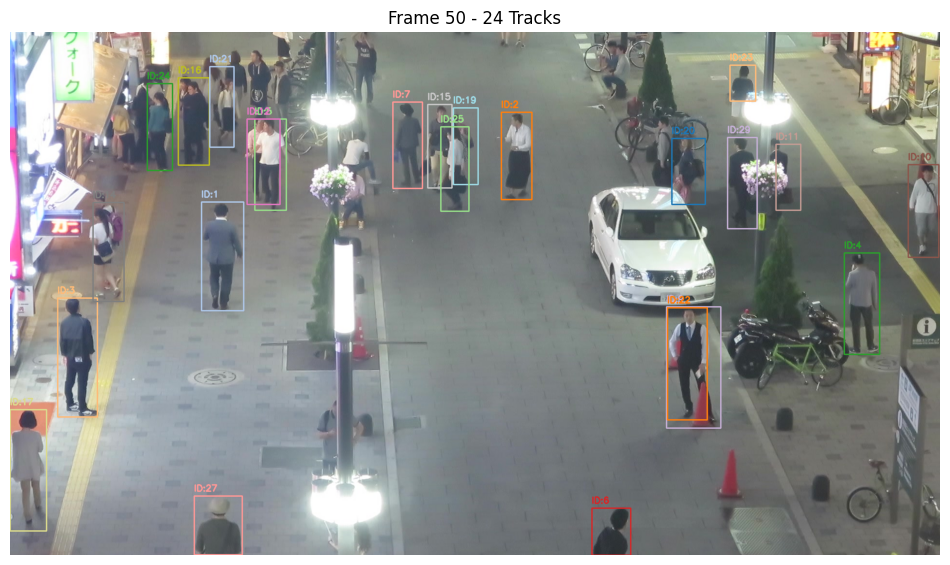

Saved: milestone1_sample_frame.png


In [7]:
# Visualize a sample frame with tracks
import cv2

# Pick a frame
sample_frame_idx = 50
sample_img = cv2.imread(image_files[sample_frame_idx])
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Get tracks for this frame
frame_tracks = [t for t in all_tracks if t['frame'] == sample_frame_idx]

# Draw tracks
colors = plt.cm.tab20(np.linspace(0, 1, 20))
for track in frame_tracks:
    x1, y1, x2, y2 = [int(v) for v in track['bbox']]
    track_id = track['track_id']
    color = tuple(int(c * 255) for c in colors[track_id % 20][:3])
    
    cv2.rectangle(sample_img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(sample_img, f'ID:{track_id}', (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(12, 8))
plt.imshow(sample_img)
plt.title(f'Frame {sample_frame_idx} - {len(frame_tracks)} Tracks')
plt.axis('off')
plt.savefig('milestone1_sample_frame.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: milestone1_sample_frame.png")

---
## Save Results
---

In [9]:
# Save results to JSON
results = {
    'config': {
        'model': 'yolov8n',
        'tracker': 'OC-SORT',
        'num_frames': len(image_files),
        'dataset': 'MOT17-04-DPM'
    },
    'metrics': {
        'avg_frame_time_ms': avg_frame_time,
        'avg_detection_time_ms': avg_det_time,
        'avg_tracking_time_ms': avg_track_time,
        'fps': fps,
        'avg_detections_per_frame': avg_detections,
        'avg_tracks_per_frame': avg_tracks,
        'unique_track_ids': unique_tracks,
        'avg_confidence': avg_confidence
    },
    'tracks': all_tracks[:100]  # First 100 for brevity
}

with open('milestone1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFiles Generated:")
print("- milestone1_results.png")
print("- milestone1_sample_frame.png")
print("- milestone1_results.json")


Files Generated:
- milestone1_results.png
- milestone1_sample_frame.png
- milestone1_results.json
